# Lab 9

By Niksh Hiremath (U20240158)


## 1. Code


### Importing libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [3]:
np.random.seed(0)

### Loading dataset

In [16]:
df = pd.read_excel("factoryReports.xlsx")
df.head()

,Description,Category,Urgency,Resolution,Cost
0,Items are occasionally getting stuck in the sc...,Mechanical Failure,Medium,Readjust Machine,45
1,Loud rattling and banging sounds are coming fr...,Mechanical Failure,Medium,Readjust Machine,35
2,There are cuts to the power when starting the ...,Electronic Failure,High,Full Replacement,16200
3,Fried capacitors in the assembler.,Electronic Failure,High,Replace Components,352
4,Mixer tripped the fuses.,Electronic Failure,Low,Add to Watch List,55


### Preprocessing


In [10]:
stop_words = stopwords.words("english")

In [ ]:
def clean_description(text):
    text = text.lower()
    tokens = word_tokenize(text)
    return " ".join(t for t in tokens if t.isalpha() and t not in stop_words)


df["Description"] = df["Description"].apply(clean_description)
df["Category"] = df["Category"].str.lower()

In [22]:
df.head()

,Description,Category,Urgency,Resolution,Cost
0,items occasionally getting stuck scanner spools,mechanical failure,Medium,Readjust Machine,45
1,loud rattling banging sounds coming assembler ...,mechanical failure,Medium,Readjust Machine,35
2,cuts power starting plant,electronic failure,High,Full Replacement,16200
3,fried capacitors assembler,electronic failure,High,Replace Components,352
4,mixer tripped fuses,electronic failure,Low,Add to Watch List,55


### TFIDF Vectorization

In [24]:
X = df["Description"]
y = df["Category"]

In [25]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=0)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((96, 413), (384, 413), (96,), (384,))

### Random Forest Classifier

In [29]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluation

In [30]:
y_pred = rfc.predict(X_test)

In [33]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

Accuracy: 76.04%


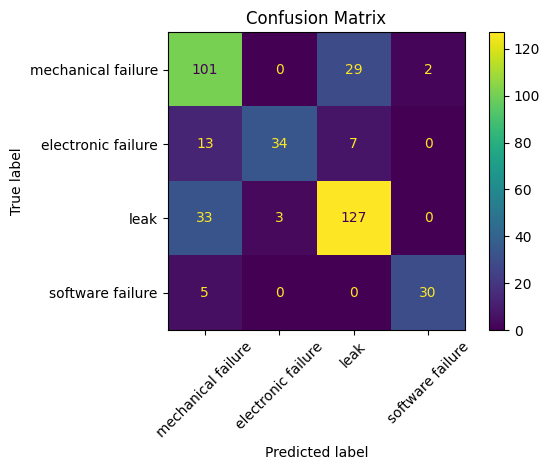

In [39]:
cm = confusion_matrix(y_test, y_pred)
labels = y.unique()

disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [43]:
n_estimators = range(10, 501, 10)
accuracies = []

for n in n_estimators:
    rfc = RandomForestClassifier(n_estimators=n, random_state=42)
    rfc.fit(X_train, y_train)
    y_pred = rfc.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

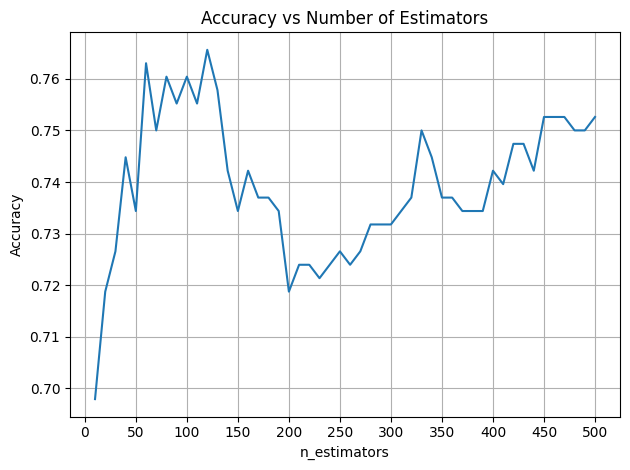

In [64]:
plt.plot(n_estimators, accuracies)

plt.xticks(range(0, 501, 50))

plt.title("Accuracy vs Number of Estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")

plt.grid()
plt.tight_layout()
plt.show()

### Best Model

In [65]:
best_n = n_estimators[np.argmax(accuracies)]
print(f"Best n_estimators = {best_n}")

Best n_estimators = 120


In [66]:
rfc = RandomForestClassifier(n_estimators=best_n, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=120, random_state=42)

In [69]:
y_pred = rfc.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy of Best Model: {acc:.2%}")

Accuracy of Best Model: 76.56%


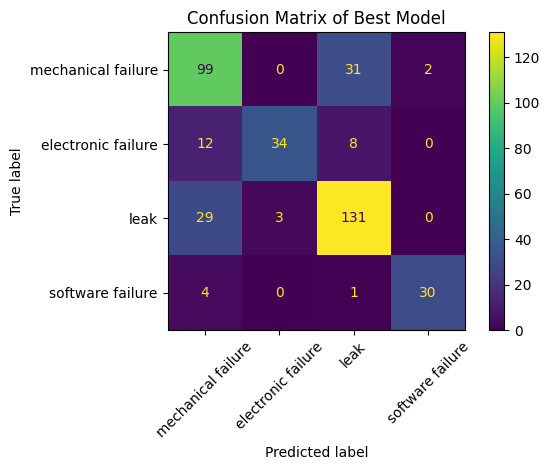

In [68]:
cm = confusion_matrix(y_test, y_pred)
labels = y.unique()

disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix of Best Model")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2. Report

### Q1: Which techniques would you use for keyword normalization in NLP, the process of converting a keyword into its base form?

**Ans:**

- **Stemming:**

  - Generates the base word from the given word by removing the affixes of the word.
  
  - It does not always result in semantically meaningful base words.

  - Is is faster and computationally less expensive.

- **Lemmatization:**

  - Lemmatization involves grouping together the inflected forms of the same word.

  - The base form (lemma) of any word is meaningful.

---


### Q2: What is TF-IDF in NLP?

**Ans:**

- TF-IDF (Term Frequency-Inverse Document Frequency) is used to evaluate how important a word is to a document in relation to a larger collection of documents.

- It is the product of Term Frequency (TF) and Inverse Document Frequency (IDF).

---


### Q3: What are some alternatives for TF-IDF method to parse text data?

**Ans:**

- **Bag of Words:** Represents text as term frequency

- **Word2Vec:** Learns lower dimensional word embeddings which captures semantic meaning.

---


### Q4: What advantage(s) does word2vec has over TF-IDF?

**Ans:**

- Word2vec captures semantic similarity, where as TF-IDF doesn't.

- Word2vec produces lower dimentional embeddings compared to TF-IDF.

---


### Q5: Provide two applications of the above lab assignment problem.

**Ans:**

- Email spam detection

- Customer feedback classification

---
